# Phase II — Linear and Regularized Models
## Bank Marketing Dataset — ML Lab Project (UPC-FIB, MDS 2026)

**Authors:** Arman Bazarchi, Ines Maria Madeira Prates

---

**Prerequisites:** Run `preprocessing.ipynb` first to generate the processed data in `data/`.

This notebook trains linear models on the subscription task and studies how regularization
shapes their coefficients.

### Outline
1. Load Processed Data & Prepare Features
2. Logistic Regression — Classification (L2 / L1 penalties, effect of λ)
3. Ridge / Lasso — Regression (Linear Probability Model)
4. Coefficient Analysis — Comparing Models
5. Summary & Discussion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
## 1. Load Processed Data & Prepare Features

In [2]:
X_scaled_df = pd.read_csv('data/X_scaled.csv')       # 15 standardized numeric/encoded features
cat_features = pd.read_csv('data/cat_features.csv')   # job, marital, month, day_of_week (strings)
y = pd.read_csv('data/y.csv')['y']

# Drop 'duration' -- it is leaky (only known after the call ends), so it cannot be used
# in a realistic predictive model. It is the single strongest correlate of the target
# (r = 0.41 in preprocessing) but must be excluded from all supervised phases.
X_num = X_scaled_df.drop(columns=['duration'])

# One-hot encode the 4 categorical string columns. drop_first=True removes one level per
# feature to avoid the dummy-variable trap (perfect multicollinearity), which would otherwise
# make linear-model coefficients unstable / non-identifiable.
X_cat = pd.get_dummies(cat_features, drop_first=True).astype(int)

# Final design matrix: standardized numerics + one-hot dummies
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
feature_names = X.columns.tolist()

print(f"Numeric features (duration dropped): {X_num.shape[1]}")
print(f"One-hot categorical features:        {X_cat.shape[1]}")
print(f"Full design matrix:                  {X.shape}")
print(f"Target positive rate:                {y.mean()*100:.1f}%")

# Feature setup for Phase II:
# - We one-hot encode the categorical strings HERE rather than in preprocessing, because
#   linear models need numeric dummies, while tree models (Phase IV) will use native categories.
# - Numeric features are already standardized (zero mean, unit variance); dummies are left as
#   0/1, the standard textbook choice. This keeps dummy coefficients interpretable as the
#   effect of belonging to a category. Coefficient-magnitude comparisons below therefore focus
#   on the standardized numeric block, which is on a common scale.

Numeric features (duration dropped): 14
One-hot categorical features:        27
Full design matrix:                  (41188, 41)
Target positive rate:                11.3%


### 1.1 Train / Test Split

We use an 80/20 **stratified** split so both sets preserve the 11.3% subscription rate.

**Class imbalance** is handled inside the models via `class_weight='balanced'`, not by resampling
the data. This keeps the test set at its real-world distribution for honest evaluation, and
avoids leaking synthetic samples across the split (resampling before splitting is a classic
methodological error).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape[0]} samples, positive rate {y_train.mean()*100:.2f}%")
print(f"Test:  {X_test.shape[0]} samples, positive rate {y_test.mean()*100:.2f}%")

# Stratification keeps both splits at the same ~11.3% positive rate, so the test set remains
# a faithful sample of the real population. We never resample the test set.

Train: 32950 samples, positive rate 11.27%
Test:  8238 samples, positive rate 11.26%


---
## 2. Logistic Regression — Classification

Logistic regression is the proper linear model for binary classification: it passes a linear
combination of features through the **sigmoid** to produce a probability in (0, 1).

**Regularization convention.** scikit-learn parameterizes the penalty strength by `C`, which is
the *inverse* of the regularization weight: **C = 1/λ**.
- Small `C`  → large λ → **strong** regularization (coefficients shrink).
- Large `C`  → small λ → **weak** regularization (coefficients free to grow).

We study two penalties:
- **L2 (Ridge penalty):** shrinks all coefficients smoothly toward zero, none reach exactly zero.
- **L1 (Lasso penalty):** drives some coefficients to *exactly* zero → automatic feature selection.

### 2.1 Baseline Logistic Regression

In [4]:
logreg = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced',
                            max_iter=2000, random_state=42)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression (L2, C=1.0, class_weight='balanced')")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
print(f"F1 (Yes):  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"AUPR:      {average_precision_score(y_test, y_proba):.4f}")

# We report F1, ROC-AUC, and AUPR rather than accuracy, because the target is imbalanced
# (a trivial all-"No" model would score ~89% accuracy while being useless).
# class_weight='balanced' re-weights the loss so the minority class (subscribers) is not
# ignored -- this raises recall on the "Yes" class at the cost of some precision, which is
# the right trade-off for a marketing campaign that wants to FIND potential subscribers.

Baseline Logistic Regression (L2, C=1.0, class_weight='balanced')
              precision    recall  f1-score   support

          No       0.95      0.85      0.90      7310
         Yes       0.36      0.64      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238

F1 (Yes):  0.4579
ROC-AUC:   0.7967
AUPR:      0.4283


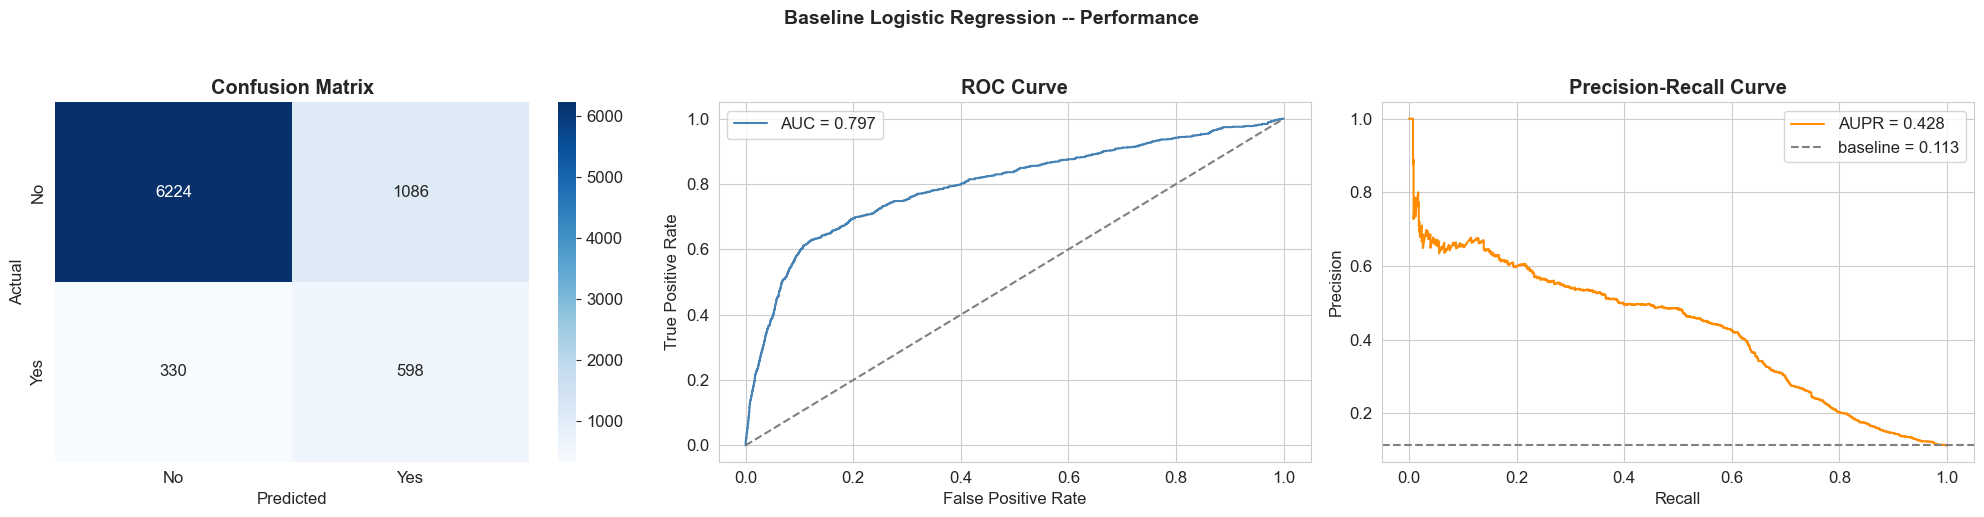

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold'); axes[1].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(rec, prec, color='darkorange', label=f'AUPR = {average_precision_score(y_test, y_proba):.3f}')
axes[2].axhline(y=y_test.mean(), linestyle='--', color='gray', label=f'baseline = {y_test.mean():.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold'); axes[2].legend()

plt.suptitle('Baseline Logistic Regression -- Performance', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Confusion matrix: with balanced weights the model recovers a large share of true subscribers
#   (high recall) but also flags many non-subscribers (false positives) -- expected given the
#   heavy class overlap we saw in Phase 1's 2D PCA projection.
# ROC-AUC well above 0.5 shows the model ranks subscribers above non-subscribers far better
#   than chance. The PR curve sits well above the 0.113 baseline, confirming real signal
#   despite the imbalance.

### 2.2 Effect of Regularization — L2 (Ridge penalty)

We sweep `C` across a wide log-range and track (a) performance and (b) the coefficient values.
This shows how the L2 penalty shrinks coefficients as regularization strengthens.

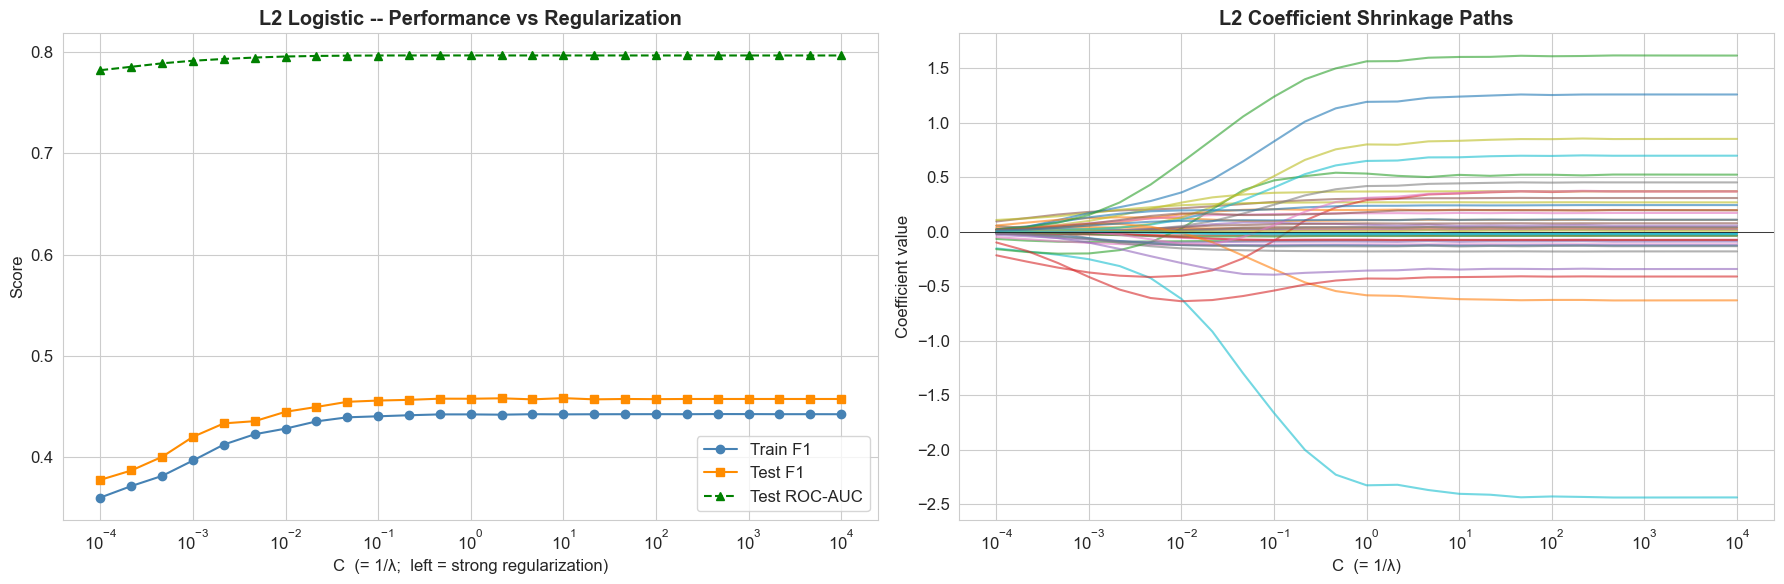

In [6]:
C_values = np.logspace(-4, 4, 25)
l2_train_f1, l2_test_f1, l2_test_auc = [], [], []
l2_coefs = []

for C in C_values:
    m = LogisticRegression(penalty='l2', C=C, class_weight='balanced',
                           max_iter=2000, random_state=42)
    m.fit(X_train, y_train)
    l2_train_f1.append(f1_score(y_train, m.predict(X_train)))
    l2_test_f1.append(f1_score(y_test, m.predict(X_test)))
    l2_test_auc.append(roc_auc_score(y_test, m.predict_proba(X_test)[:, 1]))
    l2_coefs.append(m.coef_[0])

l2_coefs = np.array(l2_coefs)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].plot(C_values, l2_train_f1, 'o-', label='Train F1', color='steelblue')
axes[0].plot(C_values, l2_test_f1, 's-', label='Test F1', color='darkorange')
axes[0].plot(C_values, l2_test_auc, '^--', label='Test ROC-AUC', color='green')
axes[0].set_xscale('log')
axes[0].set_xlabel('C  (= 1/λ;  left = strong regularization)')
axes[0].set_ylabel('Score')
axes[0].set_title('L2 Logistic -- Performance vs Regularization', fontweight='bold')
axes[0].legend()

for j in range(l2_coefs.shape[1]):
    axes[1].plot(C_values, l2_coefs[:, j], alpha=0.6)
axes[1].set_xscale('log')
axes[1].set_xlabel('C  (= 1/λ)')
axes[1].set_ylabel('Coefficient value')
axes[1].set_title('L2 Coefficient Shrinkage Paths', fontweight='bold')
axes[1].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# Performance (left): at very small C (strong λ) all coefficients are squashed and the model
#   underfits -- F1 and AUC are low. As C grows, performance rises then plateaus; train and
#   test stay close, so this linear model does not strongly overfit (it is too simple to).
# Coefficient paths (right): every coefficient shrinks smoothly toward zero as C decreases,
#   but none reaches exactly zero -- this is the defining behaviour of L2. The correlated
#   macro features (euribor3m, emp.var.rate, nr.employed) shrink together rather than one
#   dominating, because Ridge spreads weight across correlated predictors.

### 2.3 Effect of Regularization — L1 (Lasso penalty)

The L1 penalty can set coefficients to *exactly* zero. We track performance, the number of
surviving (non-zero) coefficients, and the coefficient paths.

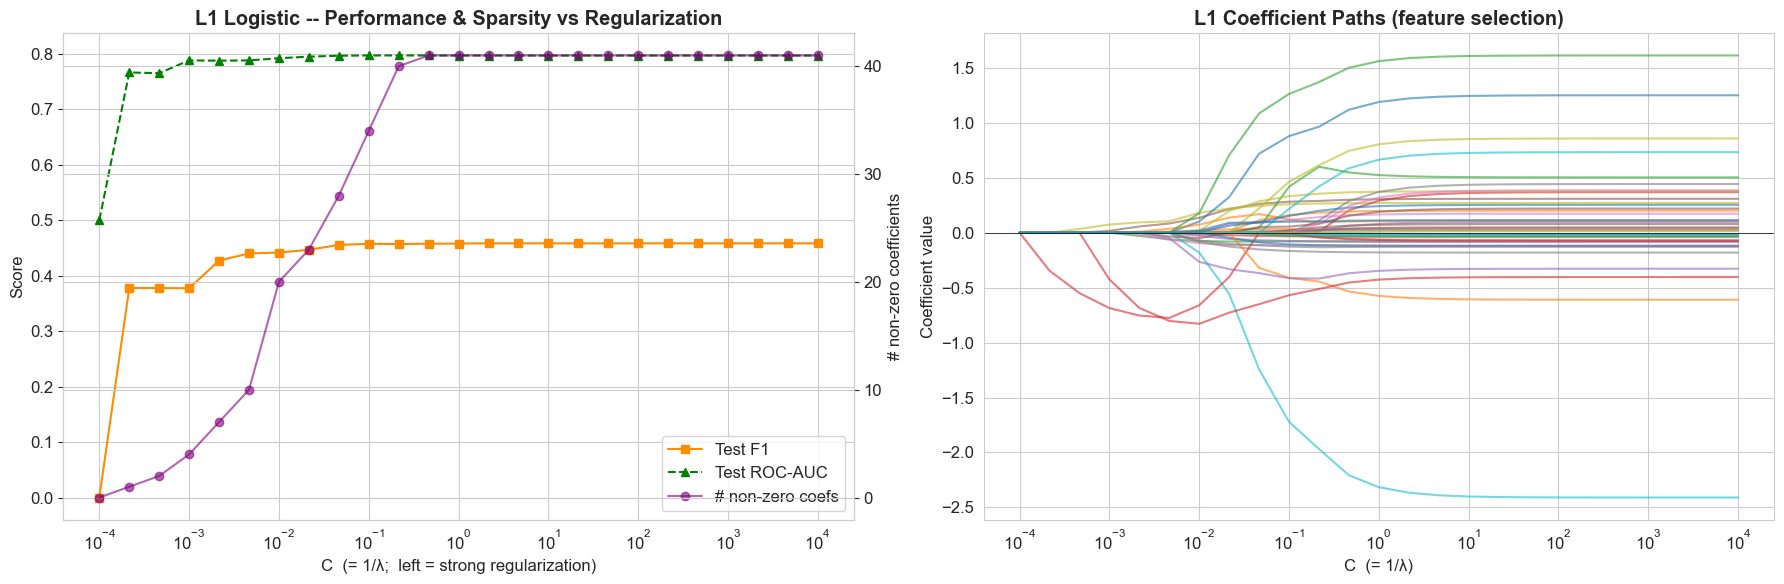

In [7]:
l1_test_f1, l1_test_auc, l1_nonzero = [], [], []
l1_coefs = []

for C in C_values:
    m = LogisticRegression(penalty='l1', C=C, class_weight='balanced',
                           solver='liblinear', max_iter=2000, random_state=42)
    m.fit(X_train, y_train)
    l1_test_f1.append(f1_score(y_test, m.predict(X_test)))
    l1_test_auc.append(roc_auc_score(y_test, m.predict_proba(X_test)[:, 1]))
    l1_nonzero.append(int(np.sum(m.coef_[0] != 0)))
    l1_coefs.append(m.coef_[0])

l1_coefs = np.array(l1_coefs)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ax2 = axes[0].twinx()
ln1 = axes[0].plot(C_values, l1_test_f1, 's-', label='Test F1', color='darkorange')
ln2 = axes[0].plot(C_values, l1_test_auc, '^--', label='Test ROC-AUC', color='green')
ln3 = ax2.plot(C_values, l1_nonzero, 'o-', label='# non-zero coefs', color='purple', alpha=0.6)
axes[0].set_xscale('log')
axes[0].set_xlabel('C  (= 1/λ;  left = strong regularization)')
axes[0].set_ylabel('Score')
ax2.set_ylabel('# non-zero coefficients')
axes[0].set_title('L1 Logistic -- Performance & Sparsity vs Regularization', fontweight='bold')
lns = ln1 + ln2 + ln3
axes[0].legend(lns, [l.get_label() for l in lns], loc='lower right')

for j in range(l1_coefs.shape[1]):
    axes[1].plot(C_values, l1_coefs[:, j], alpha=0.6)
axes[1].set_xscale('log')
axes[1].set_xlabel('C  (= 1/λ)')
axes[1].set_ylabel('Coefficient value')
axes[1].set_title('L1 Coefficient Paths (feature selection)', fontweight='bold')
axes[1].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# Sparsity (left, purple): at strong regularization (small C) only a handful of coefficients
#   are non-zero -- L1 performs automatic feature selection. As C grows, features re-enter the
#   model one by one until almost all are active.
# Coefficient paths (right): unlike L2, paths hit EXACTLY zero and stay there below some C.
#   The features whose paths survive longest (leave zero earliest as C increases) are the most
#   informative -- we identify them explicitly in the next cell.
# Performance is comparable to L2 once C is moderate, but L1 reaches it with fewer features,
#   giving a simpler, more interpretable model.

In [ ]:
# Which features does L1 keep under strong regularization? (most informative survivors)
strong_C = 0.05
m_sparse = LogisticRegression(penalty='l1', C=strong_C, class_weight='balanced',
                              solver='liblinear', max_iter=2000, random_state=42)
m_sparse.fit(X_train, y_train)

survivors = pd.Series(m_sparse.coef_[0], index=feature_names)
survivors = survivors[survivors != 0].sort_values(key=abs, ascending=False)

print(f"Features surviving strong L1 regularization (C={strong_C}):")
print("=" * 55)
print(survivors.round(4).to_string())
print(f"\n{len(survivors)} of {len(feature_names)} features retained")

# 29/41 features survive at C=0.05. The strongest survivor is emp.var.rate (-1.30), and notably
# L1 keeps emp.var.rate and cons.price.idx as the macro representatives while almost zeroing the
# collinear euribor3m (0.09) and dropping nr.employed entirely. This is Lasso's signature under
# multicollinearity: from the correlated macro trio (|r|>0.9, flagged in preprocessing) it keeps
# one or two representatives and discards the redundant rest, rather than spreading weight across all.
#
# The other survivors match the EDA signals directly: high-/low-rate calendar months
# (mar +, may/nov/jun -, aug +), contact type, poutcome (prior success), job_retired and
# job_student. So L1 recovers, from a supervised angle, the same drivers EDA and Phase 1
# highlighted -- while automatically collapsing the redundant macro block.

---
## 3. Ridge / Lasso — Regression (Linear Probability Model)

The project asks us to also study **Ridge** and **Lasso** in a *regression* setting. Our dataset
has a single response of interest — subscription `y ∈ {0,1}` — so rather than inventing an
artificial continuous target, we apply Ridge and Lasso directly to this binary outcome. Regularized
linear regression on a 0/1 response is the **Linear Probability Model (LPM)**.

**Why this is the right choice for our case:**
- It keeps the whole phase focused on one business problem, so regression and classification
  coefficients are directly comparable on *identical features and the same target*.
- It cleanly isolates regularization's effect — how λ shrinks coefficients (Ridge) and selects
  features (Lasso) — on the data we actually care about.
- The contrast with logistic regression is itself the lesson: Section 3.3 shows the LPM produces
  predictions outside [0, 1], which is exactly *why* classification needs the logistic link.

**Convention.** Ridge/Lasso use `alpha = λ` directly (the opposite of logistic's `C`):
large `alpha` → strong regularization.

**Caveat.** The LPM violates linear-regression assumptions (predictions unbounded, heteroskedastic
errors) — which is precisely why logistic regression exists. We use it here as a didactic
regularization study, not as our final classifier.

### 3.1 Ridge Regression — Coefficient Shrinkage vs λ

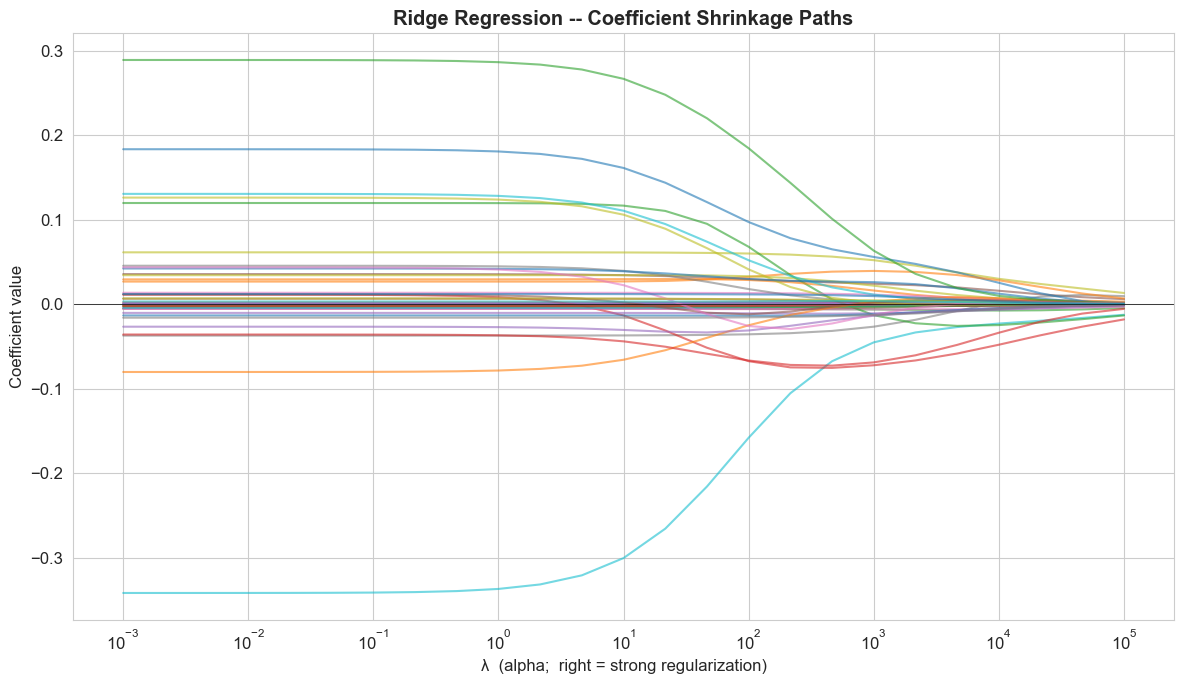

In [9]:
alphas_ridge = np.logspace(-3, 5, 25)
ridge_coefs = []
for a in alphas_ridge:
    r = Ridge(alpha=a)
    r.fit(X_train, y_train)
    ridge_coefs.append(r.coef_)
ridge_coefs = np.array(ridge_coefs)

plt.figure(figsize=(12, 7))
for j in range(ridge_coefs.shape[1]):
    plt.plot(alphas_ridge, ridge_coefs[:, j], alpha=0.6)
plt.xscale('log')
plt.xlabel('λ  (alpha;  right = strong regularization)')
plt.ylabel('Coefficient value')
plt.title('Ridge Regression -- Coefficient Shrinkage Paths', fontweight='bold')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# As λ grows, Ridge shrinks every coefficient smoothly toward zero but NONE reaches exactly
# zero -- the same L2 behaviour we saw in the logistic model. The correlated macro features
# shrink together: Ridge handles multicollinearity by distributing weight among the correlated
# predictors rather than arbitrarily picking one. This stabilizes coefficients (the instability
# we flagged in preprocessing from |r|>0.9 among euribor3m / emp.var.rate / nr.employed).

### 3.2 Lasso Regression — Feature Selection vs λ

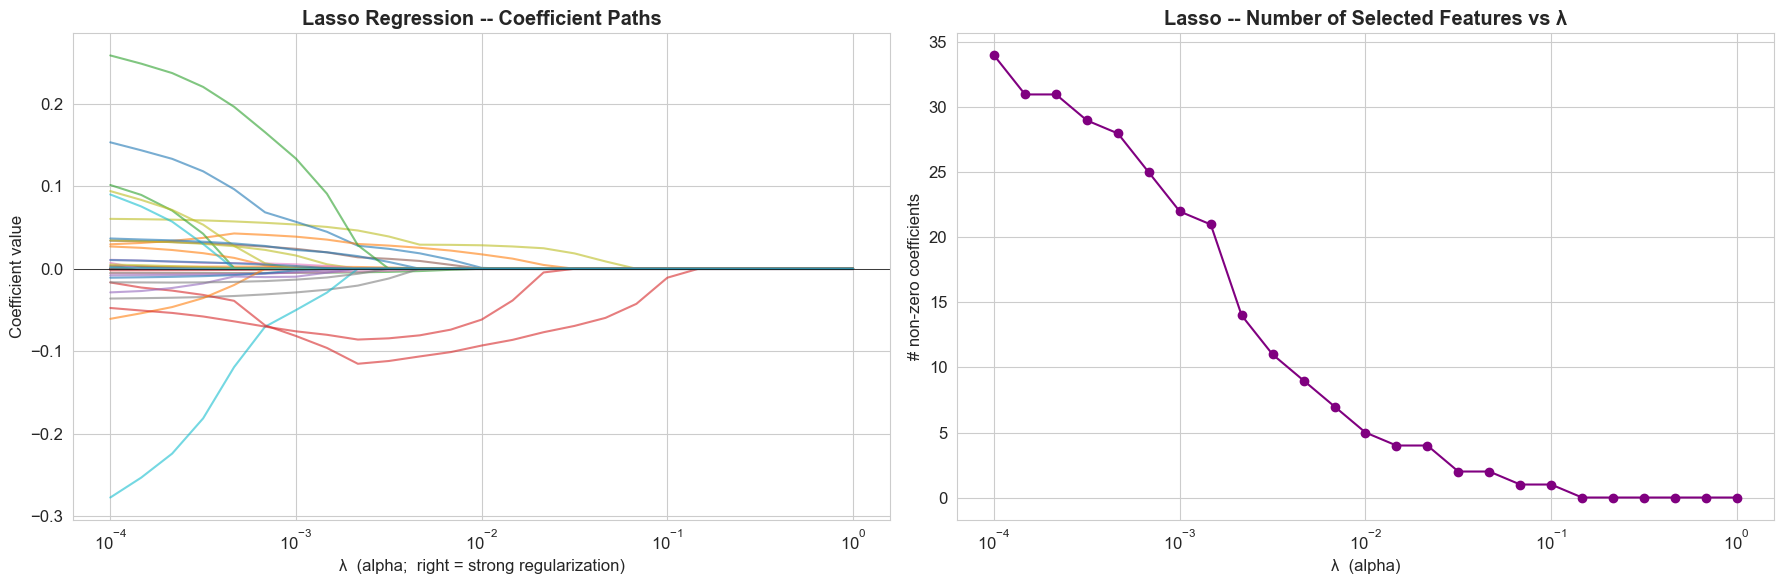

In [10]:
alphas_lasso = np.logspace(-4, 0, 25)
lasso_coefs = []
lasso_nonzero = []
for a in alphas_lasso:
    l = Lasso(alpha=a, max_iter=5000)
    l.fit(X_train, y_train)
    lasso_coefs.append(l.coef_)
    lasso_nonzero.append(int(np.sum(l.coef_ != 0)))
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for j in range(lasso_coefs.shape[1]):
    axes[0].plot(alphas_lasso, lasso_coefs[:, j], alpha=0.6)
axes[0].set_xscale('log')
axes[0].set_xlabel('λ  (alpha;  right = strong regularization)')
axes[0].set_ylabel('Coefficient value')
axes[0].set_title('Lasso Regression -- Coefficient Paths', fontweight='bold')
axes[0].axhline(y=0, color='black', linewidth=0.5)

axes[1].plot(alphas_lasso, lasso_nonzero, 'o-', color='purple')
axes[1].set_xscale('log')
axes[1].set_xlabel('λ  (alpha)')
axes[1].set_ylabel('# non-zero coefficients')
axes[1].set_title('Lasso -- Number of Selected Features vs λ', fontweight='bold')

plt.tight_layout()
plt.show()

# Lasso zeros out coefficients one by one as λ grows (right panel: the count drops toward zero),
# performing automatic feature selection -- the L1 behaviour, now in a regression setting.
# Crucially, among the correlated macro features Lasso tends to KEEP ONE and DROP the others,
# the opposite of Ridge which keeps them all. This is the classic Ridge-vs-Lasso contrast under
# multicollinearity: Ridge = grouped shrinkage, Lasso = sparse selection.

### 3.3 Linear vs Logistic — Why Classification Needs Logistic

The LPM treats the 0/1 target as continuous. We check whether its predictions are valid
probabilities.

Linear Probability Model (Ridge, alpha=1.0) -- test-set predictions:
  range: [-0.080, 0.824]
  predictions < 0: 262 (3.2%)
  predictions > 1: 0 (0.0%)


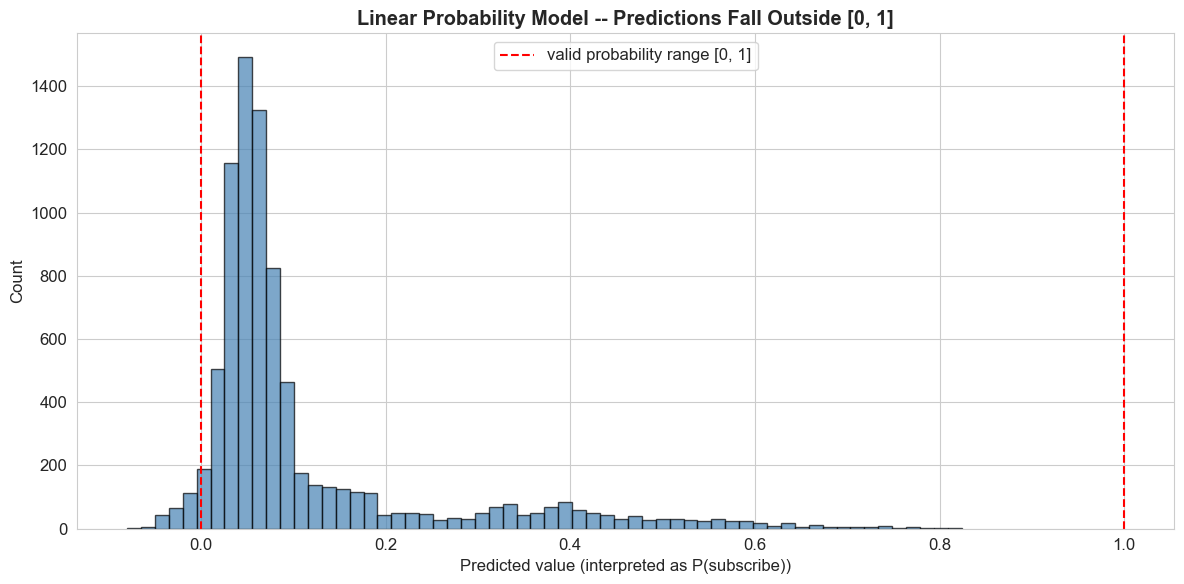

In [11]:
lpm = Ridge(alpha=1.0)
lpm.fit(X_train, y_train)
lpm_pred = lpm.predict(X_test)

n_below = int((lpm_pred < 0).sum())
n_above = int((lpm_pred > 1).sum())

print("Linear Probability Model (Ridge, alpha=1.0) -- test-set predictions:")
print("=" * 60)
print(f"  range: [{lpm_pred.min():.3f}, {lpm_pred.max():.3f}]")
print(f"  predictions < 0: {n_below} ({n_below/len(lpm_pred)*100:.1f}%)")
print(f"  predictions > 1: {n_above} ({n_above/len(lpm_pred)*100:.1f}%)")

plt.figure(figsize=(12, 6))
plt.hist(lpm_pred, bins=60, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='valid probability range [0, 1]')
plt.axvline(x=1, color='red', linestyle='--')
plt.xlabel('Predicted value (interpreted as P(subscribe))')
plt.ylabel('Count')
plt.title('Linear Probability Model -- Predictions Fall Outside [0, 1]', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# The LPM produces predictions below 0 (and can exceed 1), which are invalid as probabilities.
# Logistic regression's sigmoid bounds outputs to (0, 1) by construction, so it never does this.
# This is the core reason classification uses logistic regression rather than linear regression --
# even though BOTH can be regularized identically with L2 (Ridge) and L1 (Lasso) penalties.
# The regularization machinery is shared; the link function is what makes logistic correct here.

---
## 4. Coefficient Analysis — Comparing Models

We compare the coefficients of all four regularized linear models at a moderate regularization
level, on the same features and target.

In [ ]:
logit_l2 = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced',
                              max_iter=2000, random_state=42).fit(X_train, y_train)
logit_l1 = LogisticRegression(penalty='l1', C=1.0, class_weight='balanced',
                              solver='liblinear', max_iter=2000, random_state=42).fit(X_train, y_train)
ridge_m = Ridge(alpha=1.0).fit(X_train, y_train)
lasso_m = Lasso(alpha=0.001, max_iter=5000).fit(X_train, y_train)

coef_table = pd.DataFrame({
    'Logistic_L2': logit_l2.coef_[0],
    'Logistic_L1': logit_l1.coef_[0],
    'Ridge':       ridge_m.coef_,
    'Lasso':       lasso_m.coef_,
}, index=feature_names)

coef_table_sorted = coef_table.reindex(
    coef_table['Logistic_L2'].abs().sort_values(ascending=False).index
)
print("Coefficient comparison (top 15 features by |Logistic L2|):")
print("=" * 70)
print(coef_table_sorted.head(15).round(3).to_string())

n_lasso_zero = int((lasso_m.coef_ == 0).sum())
n_l1_zero = int((logit_l1.coef_[0] == 0).sum())
print(f"\nLasso (regression) zeroed:  {n_lasso_zero} / {len(feature_names)} features")
print(f"Logistic L1 zeroed:         {n_l1_zero} / {len(feature_names)} features")

# Logistic coefficients are on the log-odds scale; Ridge/Lasso (LPM) are on the probability
# scale -- so magnitudes differ between the two families (logistic coefs are much larger),
# but within each family the sign and ranking are consistent.
#
# Sparsity: at this moderate setting the Lasso regression has already zeroed 19/41 features,
# while the L1-logistic at C=1.0 still retains all 41 -- its regularization is simply too weak
# here to zero any (sparsity kicks in at smaller C, as shown in section 2.3). The L2 models
# (Logistic_L2, Ridge) keep every feature non-zero by construction.
#
# IMPORTANT -- sign-splitting in the macro block: emp.var.rate is strongly negative (-2.33),
# but euribor3m (+0.53), nr.employed (+0.29) and cons.price.idx (+1.19) come out POSITIVE,
# even though each is negatively correlated with the target marginally (EDA / Phase 1).
# This is the multicollinearity-driven coefficient instability we predicted in preprocessing
# (|r|>0.9 among the macro indicators): when collinear predictors enter jointly, the model
# splits the shared effect among them and individual signs/magnitudes become unreliable.
# The same happens to previous, which flips negative because it is collinear with poutcome.

In [ ]:
top_k = 15
top_feats = coef_table['Logistic_L2'].abs().sort_values(ascending=False).head(top_k).index
plot_df = coef_table.loc[top_feats, 'Logistic_L2'].sort_values()

plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in plot_df.values]
plt.barh(range(len(plot_df)), plot_df.values, color=colors, edgecolor='black')
plt.yticks(range(len(plot_df)), plot_df.index)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.xlabel('Coefficient (log-odds)')
plt.title(f'Top {top_k} Logistic Regression Coefficients (L2, C=1.0)', fontweight='bold')
plt.tight_layout()
plt.show()

# Positive coefficients (green) raise subscription odds; negative (red) lower them.
# - The clearest STABLE drivers match EDA: calendar months (mar, aug, dec, sep positive;
#   may, jun, nov negative), contact=cellular, job_retired, marital_unknown, and poutcome
#   (prior campaign success) -- all positive, consistent with what we saw in the categorical EDA.
# - emp.var.rate is the single largest coefficient (strongly negative): a worsening economy
#   sharply suppresses subscription.
#
# Caution on the macro block: while emp.var.rate is negative, its collinear partners euribor3m,
# nr.employed and cons.price.idx appear POSITIVE here -- the opposite of their marginal
# correlations. As explained in the previous cell, this sign-splitting is multicollinearity,
# not a real reversal of effect. The takeaway: the macro economy is clearly the dominant force
# (it owns the largest coefficient), but with |r|>0.9 among the indicators we cannot read the
# individual macro coefficients as separate causal effects.
#
# Overall this confirms Phase 1's structure -- macro economy + campaign history dominate -- and
# the coefficient instability itself is a key argument for the dimensionality reduction (PCA),
# grouped shrinkage (Ridge), and non-linear models explored in the other phases.

---
## 5. Summary & Discussion

### Key Findings — Phase II

**Classification (Logistic Regression):**
- A linear logistic model with `class_weight='balanced'` separates subscribers from
  non-subscribers well above chance (ROC-AUC ≈ 0.80, AUPR ≈ 0.43 vs. the 0.113 baseline),
  despite the heavy class overlap seen in Phase 1.
- Accuracy is the wrong metric under imbalance — we evaluate with F1, ROC-AUC, and AUPR.

**Effect of regularization (λ):**
- **L2 / Ridge** shrinks all coefficients smoothly toward zero as λ grows (C shrinks) but never
  to exactly zero; correlated macro features shrink *together*.
- **L1 / Lasso** drives coefficients to *exactly* zero, performing automatic feature selection;
  among the correlated macro features it keeps one or two representatives and drops the rest.
- Too much regularization (very small C / large λ) underfits; too little adds noise features.
  Train and test scores stay close — these linear models underfit more than they overfit.

**Coefficient analysis:**
- The macroeconomic economy is the **dominant force** (`emp.var.rate` carries the single largest
  coefficient) and campaign history (`poutcome` = prior success) and `contact` = cellular are
  leading positive drivers — consistent with Phase 1 (PC1 = macro economy, PC2 = campaign history).
- However, the highly collinear macro block (|r|>0.9) shows **sign-splitting**: `emp.var.rate` is
  strongly negative while `euribor3m`, `nr.employed`, and `cons.price.idx` turn positive — the
  opposite of their marginal correlations. This is the **coefficient instability predicted in
  preprocessing**, not a real effect reversal. With collinear predictors, individual linear
  coefficients cannot be read as separate causal effects.
- This instability is itself a key argument for dimensionality reduction (PCA, Phase 1), grouped
  shrinkage (Ridge), and L1 selection — all of which tame the redundant macro block.

**Linear vs logistic:**
- The Linear Probability Model produces predictions outside [0, 1] (≈3% of test predictions go
  below 0), which are invalid as probabilities — demonstrating why classification requires the
  logistic link even though the Ridge/Lasso regularization machinery is identical.

**Implications for later phases:**
- Linear models capture the main effects but cannot model the feature *interactions* and
  non-linear boundary that Phase 1 anticipated → motivating kernel SVM (Phase III) and
  ensemble / tree methods (Phase IV).

---

*Phase III will focus on Support Vector Machines (linear and RBF kernels).*